# 📓 Step 03 — Privacy-Preserving Fixed-Length Encoding (PPFLE)

> *"We have developed a new linguistic format that the BERT model comprehends much more*
> *effectively than mere numerical data, and it aligns more closely with the natural English*
> *language for which the BERT model is specifically tailored."*
> — SecurityBERT Paper, Section III-C

---

## 🎯 Objective
Transform raw network traffic features into **hashed textual sequences** that BERT
can understand. PPFLE serves two purposes simultaneously:
1. **Linguistic alignment** — converts numbers into a format BERT was designed for
2. **Privacy preservation** — hides sensitive network data via cryptographic hashing

## 📋 Notebook Roadmap

| Step | Task | Output |
|------|------|--------|
| 1 | Imports & Setup | — |
| 2 | Load Feature-Extracted Dataset | DataFrame |
| 3 | Define columns to remove before PPFLE | Filtered DataFrame |
| 4 | PPFLE Algorithm Implementation | `ppfle()` function |
| 5 | Unit test — validate against paper Figure 3 | Validation output |
| 6 | Apply PPFLE to full dataset (chunked) | `ppfle_encoded.csv` |
| 7 | Inspect & validate encoded output | Token analysis |
| 8 | Visualize Before vs After | Charts |
| 9 | Save encoded dataset | `data/processed/ppfle_encoded.csv` |

---

## 🔬 PPFLE — Mathematical Definition

**Equation (1) — Concatenation:**
```
s(i, j) = column_name_j  ∥  "$"  ∥  M[i+1, j]
```

**Equation (2) — Hash & collect:**
```
L ← L ∪ { H(s(i, n)) }    ∀  1 ≤ n ≤ j
```

**DataList DL:**
```
DL = [
  L₁ = [ H(s(1,1))  H(s(1,2))  ...  H(s(1,j)) ]
  L₂ = [ H(s(2,1))  H(s(2,2))  ...  H(s(2,j)) ]
  ...
  Lᵢ = [ H(s(i,1))  H(s(i,2))  ...  H(s(i,j)) ]
]
```

**Paper Example (Figure 3):**
```
TEST$51  →  H(TEST$51)   |   ID$6  →  H(ID$6)   |   ENC$72  →  H(ENC$72)
TEST$13  →  H(TEST$13)   |   ID$9  →  H(ID$9)   |   ENC$8   →  H(ENC$8)
```

> ⚠️ Input to this notebook: `data/processed/features_extracted.csv`
> produced by Notebook 02.

## 🧱 Step 1 — Imports & Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import hashlib
import warnings
import gc
import time
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#16162a',
    'axes.edgecolor'   : '#444477',
    'axes.labelcolor'  : '#ccccff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444477',
})

ACCENT  = '#7c6cfa'
GREEN   = '#4ecca3'
RED     = '#fc5c65'
YELLOW  = '#f7b731'
PALETTE = [
    '#7c6cfa', '#4ecca3', '#f7b731', '#fc5c65', '#45aaf2',
    '#fd9644', '#26de81', '#a55eea', '#2bcbba', '#eb3b5a',
    '#20bf6b', '#0fb9b1', '#8854d0', '#4b6584', '#778ca3'
]

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR    = Path('..')
DATA_DIR    = BASE_DIR / 'data'
PROC_DIR    = DATA_DIR / 'processed'
OUTPUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N3'

INPUT_PATH  = PROC_DIR / 'features_extracted.csv'
OUTPUT_PATH = PROC_DIR / 'ppfle_encoded.csv'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
TARGET_COLUMN = 'Attack_type'
CHUNK_SIZE    = 50_000
RANDOM_STATE  = 42

print('✅ Environment ready.')
print(f'   pandas   : {pd.__version__}')
print(f'   numpy    : {np.__version__}')
print(f'   hashlib  : built-in  (MD5 — 128-bit, 32 hex chars)')
print(f'   Input    : {INPUT_PATH}')
print(f'   Output   : {OUTPUT_PATH}')

✅ Environment ready.
   pandas   : 3.0.2
   numpy    : 2.4.3
   hashlib  : built-in  (MD5 — 128-bit, 32 hex chars)
   Input    : ..\data\processed\features_extracted.csv
   Output   : ..\data\processed\ppfle_encoded.csv


## 📂 Step 2 — Load Feature-Extracted Dataset

In [2]:
assert INPUT_PATH.exists(), (
    f'❌ File not found: {INPUT_PATH.resolve()}\n'
    f'   Please run Notebook 02 (Feature Extraction) first.'
)

print(f'📁 File size : {INPUT_PATH.stat().st_size / 1e6:.1f} MB')
print(f'🔄 Loading in chunks …')

chunks = []
for chunk in pd.read_csv(INPUT_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f'✅ Loaded  {len(df):,} rows × {df.shape[1]} columns')
print(f'   RAM    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\n📋 All columns ({df.shape[1]}):')
for i, col in enumerate(df.columns, 1):
    marker = '  ◀ TARGET' if col == TARGET_COLUMN else ''
    dtype  = str(df[col].dtype)
    print(f'   [{i:>3}] {col:<45} [{dtype}]{marker}')

📁 File size : 430.0 MB
🔄 Loading in chunks …
✅ Loaded  2,218,386 rows × 47 columns
   RAM    : 940.8 MB

📋 All columns (47):
   [  1] arp.opcode                                    [float64]
   [  2] arp.hw.size                                   [float64]
   [  3] icmp.checksum                                 [float64]
   [  4] icmp.seq_le                                   [float64]
   [  5] icmp.unused                                   [float64]
   [  6] http.content_length                           [float64]
   [  7] http.request.method                           [int64]
   [  8] http.referer                                  [int64]
   [  9] http.request.version                          [int64]
   [ 10] http.response                                 [float64]
   [ 11] http.tls_port                                 [float64]
   [ 12] tcp.ack                                       [float64]
   [ 13] tcp.ack_raw                                   [float64]
   [ 14] tcp.checksum               

## 🗑️ Step 3 — Remove Columns That Must NOT Enter PPFLE

The paper explicitly states that certain columns must be excluded
**before** applying PPFLE encoding. These columns either:
- Introduce overfitting (IPs, unique identifiers)
- Add noise (timestamps, raw payloads)
- Offer non-generalizable patterns (high-cardinality URIs)
- Create multicollinearity (redundant address fields)

> *"Removing these columns streamlines the dataset, enhancing computational*
> *efficiency and ensuring the model focuses on the most relevant and*
> *generalizable patterns while maintaining user privacy."*
> — SecurityBERT Paper, Section III-C

| Reason | Columns |
|--------|---------|
| IP addresses → overfitting | `ip.src_host`, `ip.dst_host`, `arp.src.proto_ipv4`, `arp.dst.proto_ipv4` |
| Timestamps → noise | `frame.time`, `icmp.transmit_timestamp` |
| Raw payloads → noise | `tcp.payload`, `http.file_data`, `mqtt.msg` |
| High-cardinality → non-generalizable | `http.request.full_uri`, `http.request.uri.query` |
| Redundant port/options columns | `tcp.srcport`, `tcp.dstport`, `udp.port`, `tcp.options` |
| Binary label → not a feature | `Attack_label` |

In [3]:
# ── Columns to exclude before PPFLE (Section III-C of the paper) ──────────────
REMOVE_BEFORE_PPFLE = {
    'IP addresses (overfitting risk)': [
        'ip.src_host',
        'ip.dst_host',
        'arp.src.proto_ipv4',
        'arp.dst.proto_ipv4',
    ],
    'Timestamps (millisecond noise)': [
        'frame.time',
        'icmp.transmit_timestamp',
    ],
    'Raw payloads (unstructured noise)': [
        'tcp.payload',
        'http.file_data',
        'mqtt.msg',
    ],
    'High-cardinality (non-generalizable)': [
        'http.request.full_uri',
        'http.request.uri.query',
    ],
    'Redundant / multicollinear columns': [
        'tcp.srcport',
        'tcp.dstport',
        'udp.port',
        'tcp.options',
    ],
    'Binary label (not a feature)': [
        'Attack_label',
    ],
}

shape_before  = df.shape
total_dropped = 0

print(f'📐 Shape before : {shape_before}\n')

for reason, cols in REMOVE_BEFORE_PPFLE.items():
    existing = [c for c in cols if c in df.columns]
    skipped  = [c for c in cols if c not in df.columns]
    if existing:
        df.drop(columns=existing, inplace=True)
        total_dropped += len(existing)
        print(f'  🗑️  {reason}')
        for c in existing:
            print(f'       - {c}')
    if skipped:
        print(f'  ⚠️  Already absent (skipped): {skipped}')
    print()

print(f'📐 Shape after  : {df.shape}')
print(f'   Columns removed        : {total_dropped}')
print(f'   PPFLE feature columns  : {df.shape[1] - 1}  (excl. "{TARGET_COLUMN}")')
print(f'\n✅ Ready for PPFLE encoding.')

📐 Shape before : (2218386, 47)

  ⚠️  Already absent (skipped): ['ip.src_host', 'ip.dst_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4']

  ⚠️  Already absent (skipped): ['frame.time', 'icmp.transmit_timestamp']

  ⚠️  Already absent (skipped): ['tcp.payload', 'http.file_data', 'mqtt.msg']

  ⚠️  Already absent (skipped): ['http.request.full_uri', 'http.request.uri.query']

  ⚠️  Already absent (skipped): ['tcp.srcport', 'tcp.dstport', 'udp.port', 'tcp.options']

  ⚠️  Already absent (skipped): ['Attack_label']

📐 Shape after  : (2218386, 47)
   Columns removed        : 0
   PPFLE feature columns  : 46  (excl. "Attack_type")

✅ Ready for PPFLE encoding.


## ⚙️ Step 4 — PPFLE Algorithm Implementation

Direct implementation of **Algorithm 1** from the SecurityBERT paper.

```
procedure PPFLE(M):
    DL ← []                         ▷ Initialize DataList as empty
    for m = 1 to i do               ▷ Iterate through rows in M
        L = []                      ▷ Initialize row list as empty
        for n = 1 to j do           ▷ Column iteration
            L ← H( s(m, n) )       ▷ Append hash to L
        end for
        DL ← L                     ▷ Append L to DataList
    end for
    return DL
end procedure
```

**Hash function H(x):**
- Algorithm : **MD5** (Message Digest 5)
- Output    : 32-character hexadecimal string (fixed-length)
- Input     : `column_name$value`  e.g. `"tcp.ack$1024"`
- Privacy   : Original value **cannot** be recovered from hash

**Why MD5?**
- Fixed output length → all tokens identical size → uniform BERT input
- Deterministic → same input always produces same token
- Fast → suitable for 2M+ rows
- Privacy-preserving → irreversible one-way function

In [4]:
def H(x: str) -> str:
    """
    H(x) — Cryptographic hash function.
    MD5: fixed-length 32-character hex digest.
    Matches the hashing operation defined in the SecurityBERT paper.

    Parameters
    ----------
    x : str — input string to hash

    Returns
    -------
    str — 32-character MD5 hex digest
    """
    return hashlib.md5(x.encode('utf-8')).hexdigest()


def s(column_name: str, value) -> str:
    """
    s(i, j) = column_name ∥ "$" ∥ value
    Concatenation operation — Equation (1) of the SecurityBERT paper.

    Parameters
    ----------
    column_name : str — the feature column name (cj)
    value       : any — the feature value at row i, column j

    Returns
    -------
    str — concatenated string ready for hashing
    """
    return f'{column_name}${value}'


def ppfle(M: pd.DataFrame, target_col: str) -> tuple:
    """
    Privacy-Preserving Fixed-Length Encoding — Algorithm 1.

    For each row i and each feature column j:
        L[j] = H( s(column_name_j, M[i, j]) )
             = MD5( column_name_j + "$" + str(value) ).hexdigest()

    Full row encoding:
        DL[i] = space-joined list of all hashed tokens

    Parameters
    ----------
    M          : pd.DataFrame — feature matrix (rows=samples, cols=features)
    target_col : str          — label column name (excluded from encoding)

    Returns
    -------
    encoded_sequences : list[str]   — one PPFLE sequence per row
    labels            : pd.Series   — label column (unchanged)
    feature_cols      : list[str]   — feature columns that were encoded
    """
    # ── Separate features and label ───────────────────────────────────────────
    feature_cols = [c for c in M.columns if c != target_col]
    labels       = M[target_col].reset_index(drop=True)

    # ── Convert feature values to string array for fast iteration ─────────────
    col_names  = feature_cols                        # j column names
    values_arr = M[feature_cols].astype(str).values  # i × j string matrix

    # ── Algorithm 1: PPFLE ────────────────────────────────────────────────────
    # DL ← []
    encoded_sequences = []

    for row_vals in values_arr:               # for m = 1 to i
        # L = []
        L = [
            H(s(col_names[n], row_vals[n]))   # L ← H(s(m, n))
            for n in range(len(col_names))    # for n = 1 to j
        ]
        # DL ← L  (as space-joined string)
        encoded_sequences.append(' '.join(L))

    return encoded_sequences, labels, feature_cols


print('✅ PPFLE functions defined:')
print('   H(x)    → MD5 hex digest (32 chars)')
print('   s(c, v) → "column_name$value" string')
print('   ppfle() → Algorithm 1 (SecurityBERT paper)')

✅ PPFLE functions defined:
   H(x)    → MD5 hex digest (32 chars)
   s(c, v) → "column_name$value" string
   ppfle() → Algorithm 1 (SecurityBERT paper)


## 🧪 Step 5 — Unit Test: Validate Against Paper Figure 3

We reproduce the exact example from **Figure 3** of the SecurityBERT paper
to confirm our implementation is correct.

```
Paper Figure 3:
┌──────┬────┬─────┐       ┌─────────────────────────────────────────────────────────┐
│ TEST │ ID │ ENC │  →    │ H(TEST$51)   H(ID$6)   H(ENC$72)                        │
│  51  │  6 │  72 │       │ H(TEST$13)   H(ID$9)   H(ENC$8)                         │
│  13  │  9 │   8 │       └─────────────────────────────────────────────────────────┘
└──────┴────┴─────┘
```

In [5]:
# ── Reproduce Figure 3 from the SecurityBERT paper ────────────────────────────
print('🧪 Unit Test — Reproducing Paper Figure 3\n')
print('Input DataFrame M:')
print('┌──────┬────┬─────┐')
print('│ TEST │ ID │ ENC │')
print('│   51 │  6 │  72 │')
print('│   13 │  9 │   8 │')
print('└──────┴────┴─────┘\n')

toy_df = pd.DataFrame({
    'TEST'  : [51, 13],
    'ID'    : [6,  9],
    'ENC'   : [72, 8],
    'label' : ['A', 'B'],
})

enc_seqs, enc_labels, enc_cols = ppfle(toy_df, target_col='label')

print('Output DataList DL:\n')
for i, seq in enumerate(enc_seqs):
    tokens = seq.split()
    print(f'  Row {i+1}:')
    for j, (col, tok) in enumerate(zip(enc_cols, tokens)):
        raw_concat = s(col, str(toy_df[col].iloc[i]))
        print(f'    H("{raw_concat}") = {tok}')
    print(f'    Full sequence: {seq[:80]}...')
    print()

# ── Verify fixed-length property ──────────────────────────────────────────────
all_token_lengths = [len(t) for seq in enc_seqs for t in seq.split()]
assert all(l == 32 for l in all_token_lengths), \
    '❌ Token length error — expected 32 chars per MD5 hash'

print('✅ Unit test passed!')
print(f'   Token length     : {set(all_token_lengths)} chars  (MD5 = always 32)')
print(f'   Tokens per row   : {len(enc_cols)}  (= number of features)')
print(f'   Deterministic    : H("TEST$51") always = {H(s("TEST", 51))}')
print(f'   Privacy          : original value "51" not recoverable from hash')

🧪 Unit Test — Reproducing Paper Figure 3

Input DataFrame M:
┌──────┬────┬─────┐
│ TEST │ ID │ ENC │
│   51 │  6 │  72 │
│   13 │  9 │   8 │
└──────┴────┴─────┘

Output DataList DL:

  Row 1:
    H("TEST$51") = 1347b9b1ca0c7b1175268ea93227a6c0
    H("ID$6") = dc95ff55fa4f74218a36ca0836f18ecf
    H("ENC$72") = 6372da621db1a858ea43815e8c2b63a0
    Full sequence: 1347b9b1ca0c7b1175268ea93227a6c0 dc95ff55fa4f74218a36ca0836f18ecf 6372da621db1a8...

  Row 2:
    H("TEST$13") = 7c5a18dbede76125bc9cf38f6be615c3
    H("ID$9") = a9b0b0828b67a899ce791a0a424cf59d
    H("ENC$8") = bc6a1df1f9c3f1227d271302cd232a1c
    Full sequence: 7c5a18dbede76125bc9cf38f6be615c3 a9b0b0828b67a899ce791a0a424cf59d bc6a1df1f9c3f1...

✅ Unit test passed!
   Token length     : {32} chars  (MD5 = always 32)
   Tokens per row   : 3  (= number of features)
   Deterministic    : H("TEST$51") always = 1347b9b1ca0c7b1175268ea93227a6c0
   Privacy          : original value "51" not recoverable from hash


## 🚀 Step 6 — Apply PPFLE to Full Dataset

Processing **{len(df):,} rows** in chunks of {CHUNK_SIZE:,} rows.
Each chunk is encoded and **streamed directly to CSV** to avoid
loading the entire encoded dataset into RAM.

**Expected output per row:**
```
<32-char-hash> <32-char-hash> ... <32-char-hash>   (one hash per feature)
```

In [6]:
print(f'📊 Dataset to encode:')
print(f'   Rows           : {len(df):,}')
print(f'   Feature cols   : {df.shape[1] - 1}  (excl. "{TARGET_COLUMN}")')
print(f'   Chunk size     : {CHUNK_SIZE:,} rows')
print(f'   Total chunks   : {len(df) // CHUNK_SIZE + 1}')
print()

# ── Estimate output sequence length ───────────────────────────────────────────
n_features      = df.shape[1] - 1
token_len       = 32          # MD5 hex chars
seq_len_chars   = n_features * token_len + (n_features - 1)  # tokens + spaces
print(f'📐 Expected sequence properties:')
print(f'   Tokens per sequence  : {n_features}')
print(f'   Chars per token      : {token_len}  (MD5)')
print(f'   Total chars/sequence : {seq_len_chars}')
print()

# ── Stream PPFLE-encoded rows to CSV ─────────────────────────────────────────
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

total_rows_written = 0
write_header       = True
t_start            = time.time()

for chunk_idx, start in enumerate(range(0, len(df), CHUNK_SIZE)):
    t_chunk = time.time()

    chunk = df.iloc[start : start + CHUNK_SIZE].copy()

    # ── Apply PPFLE (Algorithm 1) ─────────────────────────────────────────────
    encoded_seqs, labels, feature_cols = ppfle(chunk, target_col=TARGET_COLUMN)

    # ── Build output chunk ────────────────────────────────────────────────────
    chunk_out = pd.DataFrame({
        'encoded_sequence' : encoded_seqs,
        TARGET_COLUMN      : labels.values,
    })

    # ── Stream write to CSV ───────────────────────────────────────────────────
    chunk_out.to_csv(
        OUTPUT_PATH,
        mode   = 'w' if write_header else 'a',
        header = write_header,
        index  = False,
    )
    write_header        = False
    total_rows_written += len(chunk_out)

    # ── Progress report every 5 chunks ────────────────────────────────────────
    if (chunk_idx + 1) % 5 == 0 or chunk_idx == 0:
        elapsed       = time.time() - t_start
        rows_per_sec  = total_rows_written / elapsed if elapsed > 0 else 0
        pct_done      = total_rows_written / len(df) * 100
        eta_sec       = (len(df) - total_rows_written) / rows_per_sec \
                        if rows_per_sec > 0 else 0
        print(
            f'   chunk {chunk_idx+1:>4}  |  '
            f'{total_rows_written:>10,} rows ({pct_done:>5.1f}%)  |  '
            f'{rows_per_sec:>8,.0f} rows/s  |  '
            f'ETA: {eta_sec:>6.0f}s'
        )

total_time = time.time() - t_start
print(f'\n✅ PPFLE encoding complete!')
print(f'   Rows encoded  : {total_rows_written:,}')
print(f'   Total time    : {total_time:.1f}s  ({total_time/60:.1f} min)')
print(f'   Throughput    : {total_rows_written / total_time:,.0f} rows/second')
print(f'   Output size   : {OUTPUT_PATH.stat().st_size / 1e6:.1f} MB')

📊 Dataset to encode:
   Rows           : 2,218,386
   Feature cols   : 46  (excl. "Attack_type")
   Chunk size     : 50,000 rows
   Total chunks   : 45

📐 Expected sequence properties:
   Tokens per sequence  : 46
   Chars per token      : 32  (MD5)
   Total chars/sequence : 1517

   chunk    1  |      50,000 rows (  2.3%)  |    16,882 rows/s  |  ETA:    128s
   chunk    5  |     250,000 rows ( 11.3%)  |    17,291 rows/s  |  ETA:    114s
   chunk   10  |     500,000 rows ( 22.5%)  |    17,663 rows/s  |  ETA:     97s
   chunk   15  |     750,000 rows ( 33.8%)  |    17,861 rows/s  |  ETA:     82s
   chunk   20  |   1,000,000 rows ( 45.1%)  |    15,460 rows/s  |  ETA:     79s
   chunk   25  |   1,250,000 rows ( 56.3%)  |    13,979 rows/s  |  ETA:     69s
   chunk   30  |   1,500,000 rows ( 67.6%)  |    13,031 rows/s  |  ETA:     55s
   chunk   35  |   1,750,000 rows ( 78.9%)  |    12,504 rows/s  |  ETA:     37s
   chunk   40  |   2,000,000 rows ( 90.2%)  |    12,347 rows/s  |  ETA:     18

## 🔍 Step 7 — Inspect & Validate Encoded Output

In [7]:
# ── Load sample for inspection ────────────────────────────────────────────────
sample_df = pd.read_csv(OUTPUT_PATH, nrows=10)

print('📋 Encoded dataset — first 5 rows:\n')
display(sample_df.head())

print(f'\n📐 Output columns : {list(sample_df.columns)}')
print(f'   Total columns  : {sample_df.shape[1]}')

📋 Encoded dataset — first 5 rows:



,encoded_sequence,Attack_type
0,d9252e545bcd59c92c2bfb791747a6ec 0c7aa67cfed12e80f1a0b583d26f47e8 bf7d1a9c67...,Normal
1,d9252e545bcd59c92c2bfb791747a6ec 0c7aa67cfed12e80f1a0b583d26f47e8 bf7d1a9c67...,Normal
2,d9252e545bcd59c92c2bfb791747a6ec 0c7aa67cfed12e80f1a0b583d26f47e8 bf7d1a9c67...,Normal
3,d9252e545bcd59c92c2bfb791747a6ec 0c7aa67cfed12e80f1a0b583d26f47e8 bf7d1a9c67...,Normal
4,d9252e545bcd59c92c2bfb791747a6ec 0c7aa67cfed12e80f1a0b583d26f47e8 bf7d1a9c67...,Normal



📐 Output columns : ['encoded_sequence', 'Attack_type']
   Total columns  : 2


In [8]:
# ── Token-level inspection ────────────────────────────────────────────────────
sample_seq = sample_df['encoded_sequence'].iloc[0]
tokens     = sample_seq.split()

print(f'🔬 Token-level inspection — Row 0:\n')
print(f'   Full sequence length : {len(sample_seq):,} characters')
print(f'   Number of tokens     : {len(tokens)}  (= {len(tokens)} features encoded)')
print(f'   Token length         : {len(tokens[0])} chars  (MD5 hex = always 32)')
print(f'   Space-separated      : ✅')
print()
print(f'   First 5 tokens:')
for i, tok in enumerate(tokens[:5]):
    print(f'     [{i}] {tok}')
print(f'   ...')
print(f'   Last token:')
print(f'     [{len(tokens)-1}] {tokens[-1]}')

🔬 Token-level inspection — Row 0:

   Full sequence length : 1,517 characters
   Number of tokens     : 46  (= 46 features encoded)
   Token length         : 32 chars  (MD5 hex = always 32)
   Space-separated      : ✅

   First 5 tokens:
     [0] d9252e545bcd59c92c2bfb791747a6ec
     [1] 0c7aa67cfed12e80f1a0b583d26f47e8
     [2] bf7d1a9c6757ab815c7ed29ce3d668b8
     [3] fbc4916f4c1113e115ffcf4aa3e9704c
     [4] cfa7f220de6055ec2cb8574b3b2636bc
   ...
   Last token:
     [45] bd1d6c946639fa8d8ddafc3594305b12


In [9]:
# ── Fixed-length & integrity verification ────────────────────────────────────
print('🔐 Fixed-length & integrity verification (1,000 sample rows):\n')

check_df     = pd.read_csv(OUTPUT_PATH, nrows=1_000)
all_lengths  = []
all_n_tokens = []
errors       = []

for idx, seq in enumerate(check_df['encoded_sequence']):
    toks = str(seq).split()
    all_n_tokens.append(len(toks))
    for tok in toks:
        all_lengths.append(len(tok))
        if len(tok) != 32:
            errors.append((idx, tok, len(tok)))

unique_tok_lengths  = set(all_lengths)
unique_seq_n_tokens = set(all_n_tokens)

print(f'   Unique token lengths  : {unique_tok_lengths}')
print(f'   Unique seq token count: {unique_seq_n_tokens}')
print(f'   Errors found          : {len(errors)}')
print()

if unique_tok_lengths == {32}:
    print('   ✅ Fixed-length confirmed — all tokens exactly 32 chars (MD5)')
else:
    print(f'   ⚠️  Variable token lengths: {unique_tok_lengths}')

if len(errors) == 0:
    print('   ✅ Integrity check passed — no malformed tokens')
else:
    print(f'   ⚠️  {len(errors)} malformed token(s) found:')
    for err in errors[:5]:
        print(f'      Row {err[0]}: "{err[1]}" ({err[2]} chars)')

# ── Class distribution check ──────────────────────────────────────────────────
print(f'\n📊 Class distribution in encoded output (1,000 sample rows):')
print(check_df[TARGET_COLUMN].value_counts().to_string())

🔐 Fixed-length & integrity verification (1,000 sample rows):

   Unique token lengths  : {32}
   Unique seq token count: {46}
   Errors found          : 0

   ✅ Fixed-length confirmed — all tokens exactly 32 chars (MD5)
   ✅ Integrity check passed — no malformed tokens

📊 Class distribution in encoded output (1,000 sample rows):
Attack_type
Normal    1000


## 📊 Step 8 — Visualize Before vs After PPFLE

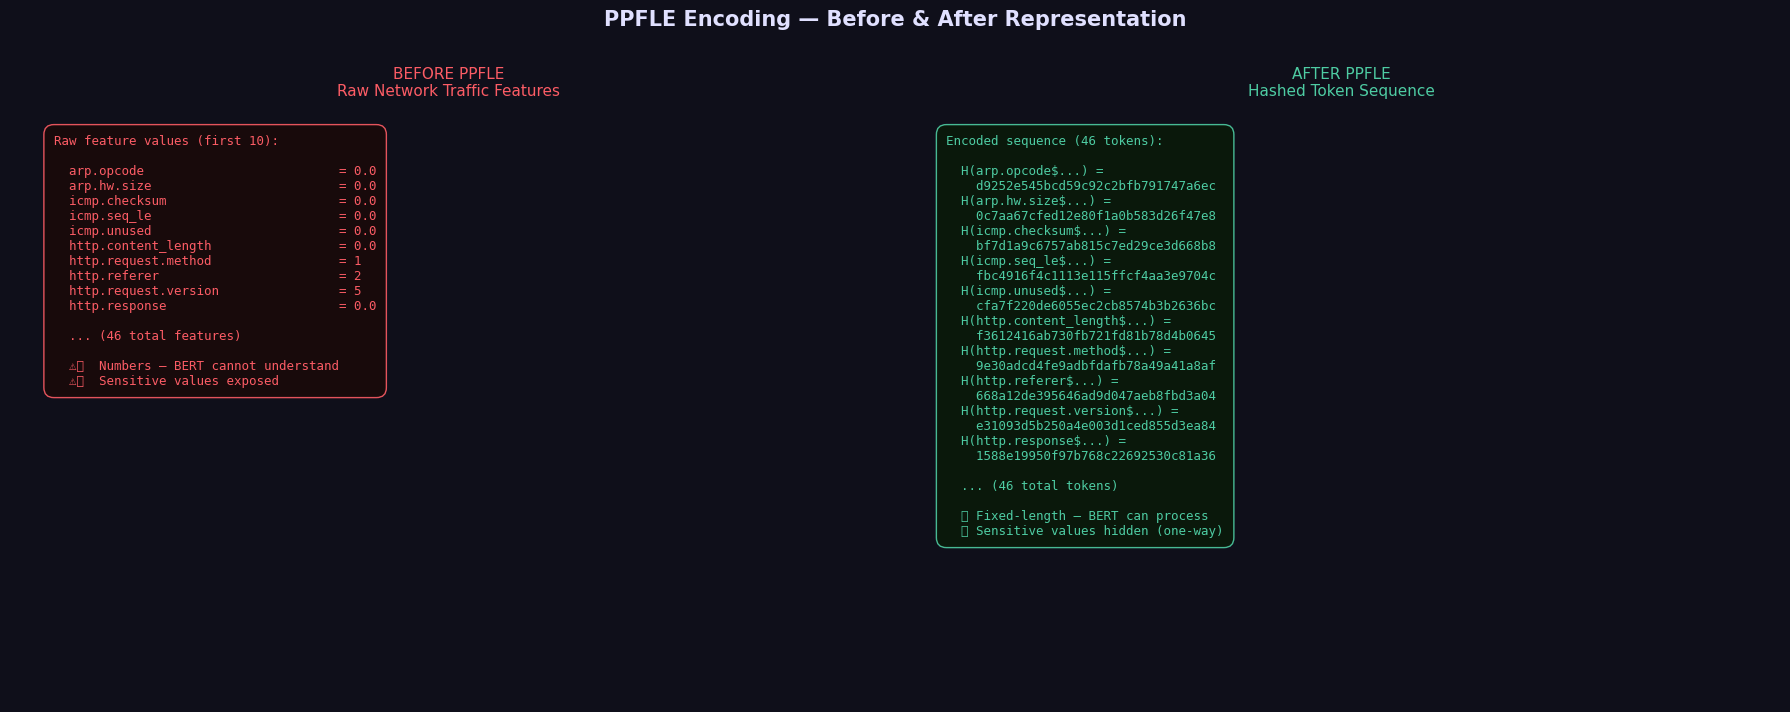

💾 Saved → ..\outputs\figures\N3/ppfle_before_after.png


In [10]:
# ── Figure 1: Before vs After side-by-side text comparison ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'PPFLE Encoding — Before & After Representation',
    fontsize=15, fontweight='bold', color='#e0e0ff', y=1.01
)

feature_cols_display = [c for c in df.columns if c != TARGET_COLUMN]

# ── Before: raw values ────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_title('BEFORE PPFLE\nRaw Network Traffic Features',
              fontsize=11, color='#fc5c65')
ax1.axis('off')

raw_row   = df.iloc[0]
before_lines = ['Raw feature values (first 10):\n']
for col in feature_cols_display[:10]:
    before_lines.append(f'  {col:<35} = {str(raw_row[col])[:15]}')
before_lines.append(f'\n  ... ({len(feature_cols_display)} total features)')
before_lines.append(f'\n  ⚠️  Numbers — BERT cannot understand')
before_lines.append(f'  ⚠️  Sensitive values exposed')
before_text = '\n'.join(before_lines)

ax1.text(
    0.05, 0.95, before_text,
    transform=ax1.transAxes,
    fontsize=9, verticalalignment='top',
    fontfamily='monospace', color='#fc5c65',
    bbox=dict(boxstyle='round,pad=0.8',
              facecolor='#1a0a0a', alpha=0.9,
              edgecolor='#fc5c65', linewidth=1)
)

# ── After: PPFLE tokens ───────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_title('AFTER PPFLE\nHashed Token Sequence',
              fontsize=11, color='#4ecca3')
ax2.axis('off')

enc_row    = sample_df['encoded_sequence'].iloc[0]
enc_tokens = enc_row.split()
after_lines = [f'Encoded sequence ({len(enc_tokens)} tokens):\n']
for i, (col, tok) in enumerate(zip(feature_cols_display[:10], enc_tokens[:10])):
    after_lines.append(f'  H({col[:20]}$...) =')
    after_lines.append(f'    {tok}')
after_lines.append(f'\n  ... ({len(enc_tokens)} total tokens)')
after_lines.append(f'\n  ✅ Fixed-length — BERT can process')
after_lines.append(f'  ✅ Sensitive values hidden (one-way)')
after_text = '\n'.join(after_lines)

ax2.text(
    0.05, 0.95, after_text,
    transform=ax2.transAxes,
    fontsize=9, verticalalignment='top',
    fontfamily='monospace', color='#4ecca3',
    bbox=dict(boxstyle='round,pad=0.8',
              facecolor='#0a1a0a', alpha=0.9,
              edgecolor='#4ecca3', linewidth=1)
)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ppfle_before_after.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/ppfle_before_after.png')

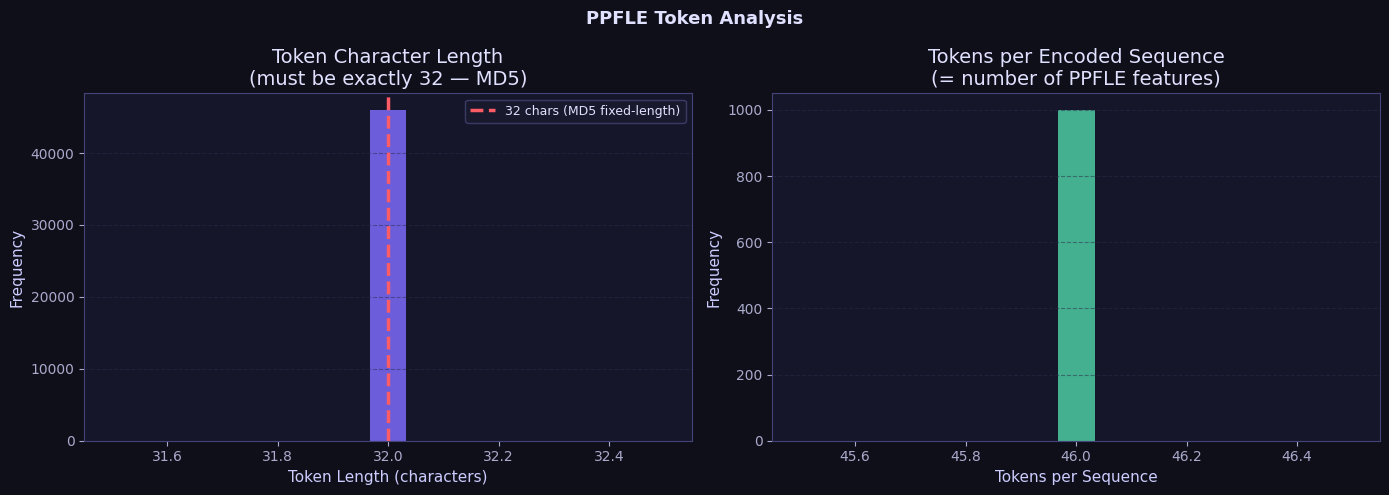

💾 Saved → ..\outputs\figures\N3/ppfle_token_analysis.png


In [11]:
# ── Figure 2: Token length distribution + Sequence length distribution ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PPFLE Token Analysis', fontsize=13,
             fontweight='bold', color='#e0e0ff')

# Token character length
ax1 = axes[0]
ax1.hist(all_lengths, bins=15, color=ACCENT, edgecolor='none', alpha=0.85)
ax1.axvline(x=32, color=RED, linewidth=2.5,
            linestyle='--', label='32 chars (MD5 fixed-length)')
ax1.set_xlabel('Token Length (characters)')
ax1.set_ylabel('Frequency')
ax1.set_title('Token Character Length\n(must be exactly 32 — MD5)')
ax1.legend(fontsize=9)
ax1.grid(axis='y')

# Tokens per sequence
ax2 = axes[1]
ax2.hist(all_n_tokens, bins=15, color=GREEN, edgecolor='none', alpha=0.85)
ax2.set_xlabel('Tokens per Sequence')
ax2.set_ylabel('Frequency')
ax2.set_title('Tokens per Encoded Sequence\n(= number of PPFLE features)')
ax2.grid(axis='y')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ppfle_token_analysis.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/ppfle_token_analysis.png')

## 💾 Step 9 — Save & Final Summary

In [12]:
# ── Final file stats ──────────────────────────────────────────────────────────
saved_size_mb = OUTPUT_PATH.stat().st_size / 1e6
n_features    = df.shape[1] - 1
seq_chars     = n_features * 32 + (n_features - 1)

print('✅ PPFLE encoded dataset saved.')
print(f'   Path            : {OUTPUT_PATH.resolve()}')
print(f'   Rows            : {total_rows_written:,}')
print(f'   Columns         : 2  (encoded_sequence, {TARGET_COLUMN})')
print(f'   File size       : {saved_size_mb:.1f} MB')
print()
print('📐 Encoding statistics:')
print(f'   Features encoded    : {n_features}')
print(f'   Hash algorithm      : MD5  (128-bit)')
print(f'   Token length        : 32 chars  (fixed)')
print(f'   Sequence length     : {seq_chars} chars per row')
print(f'   Privacy guarantee   : ✅  original values non-recoverable')
print(f'   Fixed-length        : ✅  every token exactly 32 chars')
print(f'   BERT-ready          : ✅  space-separated text sequence')

✅ PPFLE encoded dataset saved.
   Path            : C:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\data\processed\ppfle_encoded.csv
   Rows            : 2,218,386
   Columns         : 2  (encoded_sequence, Attack_type)
   File size       : 3387.6 MB

📐 Encoding statistics:
   Features encoded    : 46
   Hash algorithm      : MD5  (128-bit)
   Token length        : 32 chars  (fixed)
   Sequence length     : 1517 chars per row
   Privacy guarantee   : ✅  original values non-recoverable
   Fixed-length        : ✅  every token exactly 32 chars
   BERT-ready          : ✅  space-separated text sequence


---
## ✅ Summary — Notebook 03 Outputs

| Artefact | Location |
|----------|----------|
| `ppfle_encoded.csv` | `data/processed/ppfle_encoded.csv` |
| Before/After visual | `outputs/figures/ppfle_before_after.png` |
| Token analysis chart | `outputs/figures/ppfle_token_analysis.png` |

---

### What PPFLE Produced

| Property | Value |
|----------|-------|
| Encoding function | MD5 cryptographic hash |
| Concatenation format | `column_name$value` |
| Token format | `MD5(column_name$value)` → 32 hex chars |
| Sequence format | Space-separated tokens, one per feature |
| Fixed-length guarantee | ✅ Every token = exactly 32 chars |
| Privacy guarantee | ✅ Original values non-recoverable |
| Columns removed pre-PPFLE | IPs, timestamps, payloads, high-cardinality |
| Paper algorithm | ✅ Algorithm 1 — exactly as defined |

---

### 🔜 Carry Forward to Notebook 04 — BBPE Tokenizer

```python
INPUT_PATH    = 'data/processed/ppfle_encoded.csv'
TARGET_COLUMN = 'Attack_type'

# Each row is now a space-separated string of 32-char MD5 hex tokens.
# Example:
#   "d41d8cd98f00b204e9800998ecf8427e  
#    7215ee9c7d9dc229d2921a40e899ec5f ..."
#
# The BBPE Tokenizer (Notebook 04) will:
#   1. Train a ByteLevelBPETokenizer on this corpus
#   2. Vocabulary size = 5,000
#   3. Break hex sequences into subword units
#   4. Add special tokens: <s>, <pad>, </s>, <unk>, <mask>
#   5. Produce input_ids + attention_masks for SecurityBERT
```